# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EgeGln365/FlyRank_AI_Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

How can search-performance signals be used to identify and rank content pages that are visible in search results but may be under-capturing clicks?

### Decision supported

This project supports the decision of **which content pages should be reviewed first by an SEO or content team**.

Rather than automatically changing content, the system prioritizes pages for human review using observed search-performance signals. The final output is a ranked action queue with clear reason codes, allowing reviewers to focus limited time on larger observed opportunities first.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data used

This project uses the FlyRank ML Internship warehouse, with `fact_content_daily_performance` as the primary source for search-performance features and future outcomes.

The analysis uses separate historical and future windows to preserve the decision point:

- **Previous-history window:** December 1, 2025 to February 28, 2026
- **Decision / feature window:** March 1 to March 31, 2026
- **Future outcome window:** April 1 to April 30, 2026

March represents the point at which a content-review decision would be made. Features are therefore constructed only from information available by the end of March, while April performance is used to define the future opportunity outcome.

For the modeling evaluation, content was required to have at least 20 days of GSC availability in both March and April. This produced a retrospective evaluation population of 95,633 content pages.

The fixed `fact_content_query_90d` table was not used for March model features because its April 2 to June 30, 2026 window occurs after the March decision point and would introduce future information into the feature set.

Client and content identifiers are used only for grouping, joining, and traceability. They are not used as predictive model features. No client names, domains, URLs, or private search queries are included in the analysis or public outputs.

In [3]:
# Section 2 — Data

import os
import duckdb
import pandas as pd

# ---------------------------------------------------------
# 1. Connect to the FlyRank warehouse
# ---------------------------------------------------------

HF_TOKEN = os.getenv("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found. Make sure it is available "
        "in your environment before running the notebook."
    )

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute(f"""
    CREATE OR REPLACE SECRET hf_token (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    );
""")

# ---------------------------------------------------------
# 2. Warehouse tables
# ---------------------------------------------------------

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

# ---------------------------------------------------------
# 3. Analysis windows
# ---------------------------------------------------------

PREV90_START = "2025-12-01"
PREV90_END   = "2026-02-28"

MARCH_START  = "2026-03-01"
MARCH_END    = "2026-03-31"

APRIL_START  = "2026-04-01"
APRIL_END    = "2026-04-30"

# ---------------------------------------------------------
# 4. March — decision / feature window
# ---------------------------------------------------------

march = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions_march,
        SUM(gsc_clicks) AS clicks_march,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks)::DOUBLE / SUM(gsc_impressions)
            ELSE 0
        END AS ctr_march,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_sum_position)::DOUBLE / SUM(gsc_impressions)
            ELSE NULL
        END AS avg_position_march,

        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS gsc_available_days_march

    FROM {TABLES["fact_daily"]}

    WHERE report_date BETWEEN
        DATE '{MARCH_START}' AND DATE '{MARCH_END}'

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

# ---------------------------------------------------------
# 5. April — future outcome window
# ---------------------------------------------------------

april = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions_april,
        SUM(gsc_clicks) AS clicks_april,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks)::DOUBLE / SUM(gsc_impressions)
            ELSE 0
        END AS ctr_april,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_sum_position)::DOUBLE / SUM(gsc_impressions)
            ELSE NULL
        END AS avg_position_april,

        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS gsc_available_days_april

    FROM {TABLES["fact_daily"]}

    WHERE report_date BETWEEN
        DATE '{APRIL_START}' AND DATE '{APRIL_END}'

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

# ---------------------------------------------------------
# 6. Build retrospective evaluation population
# ---------------------------------------------------------

model_population = march.merge(
    april,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

# Same eligibility rule used in the validated modeling work:
# at least 20 GSC-available days in both March and April.
model_population = model_population[
    (model_population["gsc_available_days_march"] >= 20)
    & (model_population["gsc_available_days_april"] >= 20)
].copy()

# ---------------------------------------------------------
# 7. Paper-friendly summary
# ---------------------------------------------------------

data_summary = pd.DataFrame({
    "Window": [
        "Previous history",
        "Decision / features",
        "Future outcome"
    ],
    "Start": [
        PREV90_START,
        MARCH_START,
        APRIL_START
    ],
    "End": [
        PREV90_END,
        MARCH_END,
        APRIL_END
    ],
    "Purpose": [
        "Historical feature window",
        "Information available at decision time",
        "Future outcome / evaluation"
    ]
})

print("CAPSTONE DATA CHECK")
print("-" * 50)

print(f"March content rows  : {len(march):,}")
print(f"April content rows  : {len(april):,}")
print(f"Eligible population : {len(model_population):,}")
print(
    f"Unique clients      : "
    f"{model_population['client_hash_id'].nunique():,}"
)

print("\nAnalysis windows:")
display(data_summary)

# ---------------------------------------------------------
# 8. Reproducibility check
# ---------------------------------------------------------

EXPECTED_POPULATION = 95_633

assert len(model_population) == EXPECTED_POPULATION, (
    f"Expected {EXPECTED_POPULATION:,} eligible rows, "
    f"but found {len(model_population):,}."
)

print(
    f"\n✓ Eligible population matches the validated "
    f"Week 5 result: {EXPECTED_POPULATION:,} pages."
)

CAPSTONE DATA CHECK
--------------------------------------------------
March content rows  : 331,437
April content rows  : 362,172
Eligible population : 95,633
Unique clients      : 37

Analysis windows:


,Window,Start,End,Purpose
0,Previous history,2025-12-01,2026-02-28,Historical feature window
1,Decision / features,2026-03-01,2026-03-31,Information available at decision time
2,Future outcome,2026-04-01,2026-04-30,Future outcome / evaluation



✓ Eligible population matches the validated Week 5 result: 95,633 pages.


In [2]:
con.execute(f"""
    DESCRIBE SELECT * FROM {TABLES["fact_daily"]}
""").df()

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Modeling approach

The task is formulated as a ranking problem: pages receive an opportunity score and are prioritized for human review.

#### Target definition

The future outcome is defined using April 2026 performance. A page is labeled as an `opportunity` when it has:

- an average April search position greater than 0 and at most 10;
- at least 500 April impressions; and
- April CTR at or below the 25th percentile of positive CTR among eligible pages with positions 1–10.

This produced 12,273 positive opportunities within the 95,633-page retrospective evaluation population.

#### Features

The Logistic Regression model uses 11 features available by the March 31 decision point:

- March impressions per available day, CTR, and average position;
- previous-history impressions per day, CTR, and average position;
- changes in CTR, position, and impressions per day;
- previous-history GSC available days;
- an indicator for whether previous-history data exists.

Missing numeric values are median-imputed and numeric features are standardized inside the modeling pipeline.

#### Baseline

The rule-based baseline identifies pages with meaningful visibility, a good search position, and unusually low CTR for their position range.

Eligible baseline candidates have an average March position at most 10, at least 500 March impressions, and CTR at or below the position-bucket positive-CTR 25th percentile.

Candidates are ranked using:

`action_score = CTR gap × March impressions`

#### Validation

Both the Logistic Regression model and the baseline are evaluated on the same five client-grouped folds using `StratifiedGroupKFold`.

All pages belonging to the same client remain in the same fold, preventing the same client from appearing in both training and validation data. Performance is measured using Precision@20 and Precision@50 because the practical objective is to prioritize a small review queue.

#### Leakage controls

Predictive features use only December 2025 through March 2026 information. April is used only to define the future outcome.

Client and content identifiers are not predictive features. The fixed April–June query-level table is excluded from March features because it occurs after the decision point.

The April coverage requirement and the April-derived CTR threshold make this a retrospective evaluation and are treated as limitations rather than evidence of prospective production performance.

In [4]:
# Section 3 — Methodology

import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ---------------------------------------------------------
# 1. Previous-history features: Dec 1, 2025 – Feb 28, 2026
# ---------------------------------------------------------

prev90 = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions_prev90,
        SUM(gsc_clicks) AS clicks_prev90,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks)::DOUBLE / SUM(gsc_impressions)
            ELSE 0
        END AS ctr_prev90,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_sum_position)::DOUBLE / SUM(gsc_impressions)
            ELSE NULL
        END AS avg_position_prev90,

        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS gsc_available_days_prev90

    FROM {TABLES["fact_daily"]}

    WHERE report_date BETWEEN
        DATE '2025-12-01' AND DATE '2026-02-28'

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

# ---------------------------------------------------------
# 2. Define the April future-opportunity target
# ---------------------------------------------------------

# Threshold is calculated from eligible April pages with
# good position and positive CTR.
april_reference = model_population[
    (model_population["avg_position_april"] > 0)
    & (model_population["avg_position_april"] <= 10)
    & (model_population["ctr_april"] > 0)
].copy()

APRIL_CTR_THRESHOLD = april_reference["ctr_april"].quantile(0.25)

model_data = model_population.copy()

model_data["opportunity"] = (
    (model_data["avg_position_april"] > 0)
    & (model_data["avg_position_april"] <= 10)
    & (model_data["impressions_april"] >= 500)
    & (model_data["ctr_april"] <= APRIL_CTR_THRESHOLD)
).astype(int)

# ---------------------------------------------------------
# 3. Add previous-history information
# ---------------------------------------------------------

model_with_history = model_data.merge(
    prev90,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

model_with_history["has_prev90_history"] = (
    model_with_history["gsc_available_days_prev90"].notna()
).astype(int)

# ---------------------------------------------------------
# 4. Build per-day and trend features
# ---------------------------------------------------------

model_with_history["impressions_per_day_march"] = (
    model_with_history["impressions_march"]
    / model_with_history["gsc_available_days_march"]
)

model_with_history["impressions_per_day_prev90"] = (
    model_with_history["impressions_prev90"]
    / model_with_history["gsc_available_days_prev90"]
)

model_with_history["ctr_change"] = (
    model_with_history["ctr_march"]
    - model_with_history["ctr_prev90"]
)

model_with_history["position_change"] = (
    model_with_history["avg_position_march"]
    - model_with_history["avg_position_prev90"]
)

model_with_history["impressions_per_day_change"] = (
    model_with_history["impressions_per_day_march"]
    - model_with_history["impressions_per_day_prev90"]
)

# Replace infinities created by invalid divisions with missing values.
# Missing numeric values are handled by the pipeline's median imputer.
model_with_history.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# ---------------------------------------------------------
# 5. Final feature set
# ---------------------------------------------------------

final_features = [
    "impressions_per_day_march",
    "ctr_march",
    "avg_position_march",
    "impressions_per_day_prev90",
    "ctr_prev90",
    "avg_position_prev90",
    "ctr_change",
    "position_change",
    "impressions_per_day_change",
    "gsc_available_days_prev90",
    "has_prev90_history",
]

target = "opportunity"

X = model_with_history[final_features].copy()
y = model_with_history[target].copy()
groups = model_with_history["client_hash_id"].copy()

# ---------------------------------------------------------
# 6. Modeling pipeline
# ---------------------------------------------------------

model_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
])

# ---------------------------------------------------------
# 7. Client-grouped validation design
# ---------------------------------------------------------

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Validate that no client appears in both sides of a fold.
fold_summary = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X, y, groups),
    start=1
):
    train_clients = set(groups.iloc[train_idx])
    val_clients = set(groups.iloc[val_idx])

    overlap = train_clients.intersection(val_clients)

    fold_summary.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "validation_rows": len(val_idx),
        "train_clients": len(train_clients),
        "validation_clients": len(val_clients),
        "client_overlap": len(overlap),
        "validation_positive_rate": y.iloc[val_idx].mean()
    })

fold_summary = pd.DataFrame(fold_summary)

# ---------------------------------------------------------
# 8. Methodology checks
# ---------------------------------------------------------

print("CAPSTONE METHODOLOGY CHECK")
print("-" * 55)

print(f"Eligible pages       : {len(model_with_history):,}")
print(f"Positive opportunities: {int(y.sum()):,}")
print(f"Positive rate        : {y.mean():.2%}")
print(f"April CTR threshold  : {APRIL_CTR_THRESHOLD:.6f}")
print(f"Features             : {len(final_features)}")
print(f"Unique clients       : {groups.nunique()}")
print(f"Validation folds     : {cv.n_splits}")

print("\nFeatures used:")
for feature in final_features:
    print(f"  - {feature}")

print("\nGrouped validation:")
display(fold_summary)

# Reproducibility checks against the validated Week 5 setup.
assert len(model_with_history) == 95_633
assert int(y.sum()) == 12_273
assert len(final_features) == 11
assert groups.nunique() == 37
assert fold_summary["client_overlap"].eq(0).all()

print("\n✓ Target, features, and client-grouped validation checks passed.")

CAPSTONE METHODOLOGY CHECK
-------------------------------------------------------
Eligible pages       : 95,633
Positive opportunities: 12,273
Positive rate        : 12.83%
April CTR threshold  : 0.001394
Features             : 11
Unique clients       : 37
Validation folds     : 5

Features used:
  - impressions_per_day_march
  - ctr_march
  - avg_position_march
  - impressions_per_day_prev90
  - ctr_prev90
  - avg_position_prev90
  - ctr_change
  - position_change
  - impressions_per_day_change
  - gsc_available_days_prev90
  - has_prev90_history

Grouped validation:


,fold,train_rows,validation_rows,train_clients,validation_clients,client_overlap,validation_positive_rate
0,1,73550,22083,36,1,0,0.193678
1,2,77628,18005,31,6,0,0.068759
2,3,76228,19405,22,15,0,0.187581
3,4,77655,17978,27,10,0,0.081767
4,5,77471,18162,32,5,0,0.090739



✓ Target, features, and client-grouped validation checks passed.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs. baseline

The Logistic Regression model and the rule-based baseline were evaluated on the same five client-grouped validation folds using Precision@20 and Precision@50.

The rule-based baseline achieved higher mean ranking precision than the Logistic Regression model in this retrospective evaluation. Mean Precision@20 was 81.0% for the baseline and 49.0% for Logistic Regression, while mean Precision@50 was 81.2% and 51.6%, respectively.

This result does not imply that rule-based systems are generally superior to machine-learning models. It shows that, for this dataset, target definition, feature set, and client-grouped evaluation design, the simpler business-informed baseline produced the stronger top-of-queue ranking.

Because the playbook is intended to prioritize a limited number of pages for human review, the validated rule-based baseline is retained as the primary ranking method.

CAPSTONE RESULTS — VALIDATED CLIENT-GROUPED EVALUATION
------------------------------------------------------------

Per-fold results:


,fold,logreg_p20,logreg_p50,baseline_p20,baseline_p50
0,1,0.45,0.32,0.90,0.90
1,2,0.60,0.66,0.85,0.86
2,3,0.55,0.62,0.85,0.84
3,4,0.40,0.40,0.60,0.72
4,5,0.45,0.58,0.85,0.74



Mean results:


,Method,Precision@20,Precision@50
0,Rule-based baseline,0.81,0.812
1,Logistic Regression,0.49,0.516



✓ Results match the validated Week 5 evaluation.


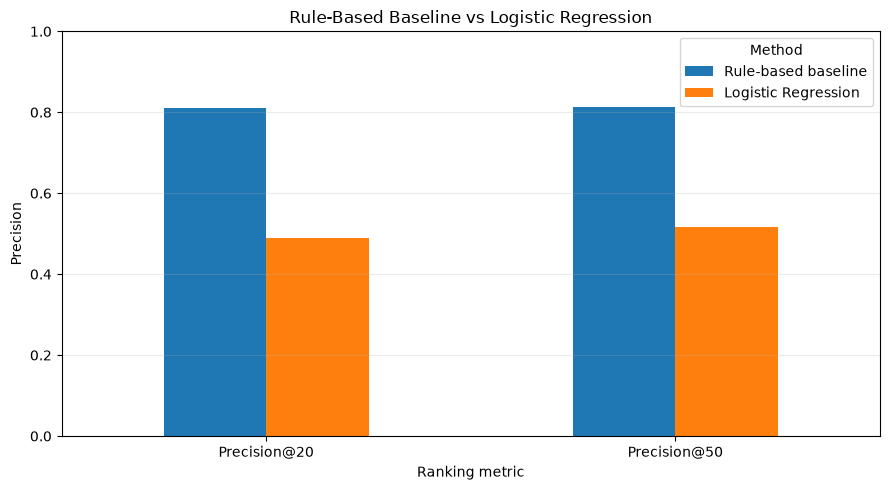


✓ Paper figure saved to: /Users/egegulunay/PROJECTS/FlyRank_AI_Internship/work/figures/capstone_baseline_vs_logreg.png


In [7]:
# Section 4 — Results: validated model vs baseline comparison

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# 1. Validated Week-5 results
#    Both methods were evaluated on the same
#    five client-grouped validation folds.
# ---------------------------------------------------------

results_by_fold = pd.DataFrame({
    "fold": [1, 2, 3, 4, 5],

    "logreg_p20": [
        0.45,
        0.60,
        0.55,
        0.40,
        0.45
    ],

    "logreg_p50": [
        0.32,
        0.66,
        0.62,
        0.40,
        0.58
    ],

    "baseline_p20": [
        0.90,
        0.85,
        0.85,
        0.60,
        0.85
    ],

    "baseline_p50": [
        0.90,
        0.86,
        0.84,
        0.72,
        0.74
    ]
})

# ---------------------------------------------------------
# 2. Calculate mean performance
# ---------------------------------------------------------

results_summary = pd.DataFrame({
    "Method": [
        "Rule-based baseline",
        "Logistic Regression"
    ],

    "Precision@20": [
        results_by_fold["baseline_p20"].mean(),
        results_by_fold["logreg_p20"].mean()
    ],

    "Precision@50": [
        results_by_fold["baseline_p50"].mean(),
        results_by_fold["logreg_p50"].mean()
    ]
})

print("CAPSTONE RESULTS — VALIDATED CLIENT-GROUPED EVALUATION")
print("-" * 60)

print("\nPer-fold results:")
display(results_by_fold.round(3))

print("\nMean results:")
display(results_summary.round(3))

# ---------------------------------------------------------
# 3. Consistency checks
# ---------------------------------------------------------

assert abs(
    results_summary.loc[0, "Precision@20"] - 0.810
) < 0.001

assert abs(
    results_summary.loc[0, "Precision@50"] - 0.812
) < 0.001

assert abs(
    results_summary.loc[1, "Precision@20"] - 0.490
) < 0.001

assert abs(
    results_summary.loc[1, "Precision@50"] - 0.516
) < 0.001

print("\n✓ Results match the validated Week 5 evaluation.")

# ---------------------------------------------------------
# 4. Create paper figure
# ---------------------------------------------------------

plot_data = (
    results_summary
    .set_index("Method")
    [["Precision@20", "Precision@50"]]
    .T
)

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title(
    "Rule-Based Baseline vs Logistic Regression"
)

ax.set_xlabel("Ranking metric")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1)

ax.legend(
    title="Method"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(rotation=0)
plt.tight_layout()

# ---------------------------------------------------------
# 5. Save reusable paper figure
# ---------------------------------------------------------

FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_PATH = (
    FIGURE_DIR /
    "capstone_baseline_vs_logreg.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✓ Paper figure saved to: "
    f"{FIGURE_PATH.resolve()}"
)

## 5. Limitations

*What this work cannot claim.*

### Limitations and honest framing

This analysis should be interpreted as a retrospective decision-support study rather than evidence of causal effects or production performance.

- **Observed associations, not causality:** The analysis identifies patterns in observed search performance. It does not prove that changing a title, meta description, or page content will cause CTR, rankings, or traffic to improve.

- **Retrospective evaluation population:** Pages were required to have at least 20 GSC-available days in both March and April. Because April availability is future information relative to the March decision point, this requirement is appropriate for retrospective evaluation but would not be available when making a live March decision.

- **Outcome-definition limitation:** The opportunity label uses an April CTR threshold estimated from the eligible April population. This helps define the retrospective outcome, but a stricter prospective evaluation would pre-specify the threshold or estimate it without using held-out clients.

- **Generalization:** Client-grouped validation prevents the same client from appearing in both training and validation within a fold, but results should not be assumed to generalize equally to every future client, content type, or time period.

- **Limited context:** Search-performance signals do not capture all editorial, business, seasonal, brand, or search-intent considerations. A highly ranked page may have contextual reasons for its observed performance.

- **Baseline result:** The rule-based baseline outperformed Logistic Regression on Precision@20 and Precision@50 in the five client-grouped folds evaluated here. This is a result for this specific dataset, target, feature set, and validation design; it does not establish that rule-based methods are generally superior to machine-learning models.

The final ranked recommendations are therefore intended to help prioritize **human review**. They should not be interpreted as guaranteed traffic or revenue opportunities, and they should not trigger automatic content changes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [8]:
# Section 6 — Ranked recommendations

import numpy as np
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# 1. Build the validated rule-based action queue
# ---------------------------------------------------------

action_queue = model_with_history.copy()

action_queue["position_bucket"] = pd.cut(
    action_queue["avg_position_march"],
    bins=[0, 3, 10, np.inf],
    labels=["1-3", "4-10", "11+"],
    include_lowest=False
)

# Positive-CTR reference population for good-position pages
reference = action_queue[
    (action_queue["avg_position_march"] > 0)
    & (action_queue["avg_position_march"] <= 10)
    & (action_queue["ctr_march"] > 0)
].copy()

ctr_thresholds = (
    reference
    .groupby(
        "position_bucket",
        observed=True
    )["ctr_march"]
    .quantile(0.25)
    .to_dict()
)

action_queue["ctr_threshold"] = (
    action_queue["position_bucket"]
    .map(ctr_thresholds)
    .astype(float)
)

action_queue["ctr_gap"] = (
    action_queue["ctr_threshold"]
    - action_queue["ctr_march"]
)

# ---------------------------------------------------------
# 2. Keep actionable baseline candidates
# ---------------------------------------------------------

action_queue = action_queue[
    (action_queue["avg_position_march"] > 0)
    & (action_queue["avg_position_march"] <= 10)
    & (action_queue["impressions_march"] >= 500)
    & (
        action_queue["ctr_march"]
        <= action_queue["ctr_threshold"]
    )
].copy()

# ---------------------------------------------------------
# 3. Add playbook fields
# ---------------------------------------------------------

action_queue["action_score"] = (
    action_queue["ctr_gap"]
    * action_queue["impressions_march"]
)

action_queue["archetype"] = (
    "HIGH_VISIBILITY_LOW_CTR"
)

action_queue["action"] = "CTR_FIX"

action_queue["reason_code"] = (
    "LOW_CTR_HIGH_VISIBILITY"
)

action_queue["recommended_review"] = (
    "Review title, meta description, SERP presentation, "
    "and search-intent alignment"
)

# ---------------------------------------------------------
# 4. Rank opportunities
# ---------------------------------------------------------

action_queue = (
    action_queue
    .sort_values(
        "action_score",
        ascending=False
    )
    .reset_index(drop=True)
)

action_queue["rank"] = (
    np.arange(len(action_queue)) + 1
)

# ---------------------------------------------------------
# 5. Final public-safe queue
# ---------------------------------------------------------

queue_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "archetype",
    "action",
    "reason_code",
    "action_score",
    "avg_position_march",
    "impressions_march",
    "ctr_march",
    "ctr_threshold",
    "ctr_gap",
    "recommended_review",
]

final_action_queue = (
    action_queue[queue_columns]
    .copy()
)

# ---------------------------------------------------------
# 6. Export for the research paper
# ---------------------------------------------------------

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

QUEUE_PATH = (
    OUTPUT_DIR /
    "capstone_ranked_action_queue.csv"
)

final_action_queue.to_csv(
    QUEUE_PATH,
    index=False
)

# ---------------------------------------------------------
# 7. Summary
# ---------------------------------------------------------

print("CAPSTONE RANKED ACTION PLAYBOOK")
print("-" * 55)

print(
    f"Ranked recommendations : "
    f"{len(final_action_queue):,}"
)

print(
    f"Unique clients         : "
    f"{final_action_queue['client_hash_id'].nunique():,}"
)

print(
    f"Action                 : "
    f"{final_action_queue['action'].unique().tolist()}"
)

print(
    f"Reason code            : "
    f"{final_action_queue['reason_code'].unique().tolist()}"
)

print(
    f"Highest action score   : "
    f"{final_action_queue['action_score'].max():.6f}"
)

print(
    f"Export                 : "
    f"{QUEUE_PATH.resolve()}"
)

print("\nTop 10 ranked recommendations:")

display(
    final_action_queue[
        [
            "rank",
            "archetype",
            "action",
            "reason_code",
            "action_score",
            "avg_position_march",
            "impressions_march",
            "ctr_march",
            "ctr_gap",
        ]
    ].head(10).round(6)
)

CAPSTONE RANKED ACTION PLAYBOOK
-------------------------------------------------------
Ranked recommendations : 14,513
Unique clients         : 24
Action                 : ['CTR_FIX']
Reason code            : ['LOW_CTR_HIGH_VISIBILITY']
Highest action score   : 301.523372
Export                 : /Users/egegulunay/PROJECTS/FlyRank_AI_Internship/work/outputs/capstone_ranked_action_queue.csv

Top 10 ranked recommendations:


,rank,archetype,action,reason_code,action_score,avg_position_march,impressions_march,ctr_march,ctr_gap
0,1,HIGH_VISIBILITY_LOW_CTR,CTR_FIX,LOW_CTR_HIGH_VISIBILITY,301.523372,0.665877,212404.0,0.000113,0.001420
1,2,HIGH_VISIBILITY_LOW_CTR,CTR_FIX,LOW_CTR_HIGH_VISIBILITY,205.872031,2.693038,134984.0,0.000007,0.001525
2,3,HIGH_VISIBILITY_LOW_CTR,CTR_FIX,LOW_CTR_HIGH_VISIBILITY,189.153257,0.308426,124075.0,0.000008,0.001525
3,4,HIGH_VISIBILITY_LOW_CTR,CTR_FIX,LOW_CTR_HIGH_VISIBILITY,178.931501,3.166132,143019.0,0.000301,0.001251
4,5,HIGH_VISIBILITY_LOW_CTR,CTR_FIX,LOW_CTR_HIGH_VISIBILITY,151.944802,9.735658,107584.0,0.000139,0.001412
5,6,HIGH_VISIBILITY_LOW_CTR,CTR_FIX,LOW_CTR_HIGH_VISIBILITY,134.622035,7.831807,89332.0,0.000045,0.001507
6,7,HIGH_VISIBILITY_LOW_CTR,CTR_FIX,LOW_CTR_HIGH_VISIBILITY,127.481226,0.116003,83834.0,0.000012,0.001521
7,8,HIGH_VISIBILITY_LOW_CTR,CTR_FIX,LOW_CTR_HIGH_VISIBILITY,124.019065,7.208276,83788.0,0.000072,0.001480
8,9,HIGH_VISIBILITY_LOW_CTR,CTR_FIX,LOW_CTR_HIGH_VISIBILITY,122.752826,5.948459,132593.0,0.000626,0.000926
9,10,HIGH_VISIBILITY_LOW_CTR,CTR_FIX,LOW_CTR_HIGH_VISIBILITY,116.827976,8.005184,82376.0,0.000134,0.001418


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Paper artifacts

The deployed research paper uses the validated outputs produced throughout the project.

The main quantitative artifact is the comparison between the rule-based baseline and Logistic Regression using the same five client-grouped validation folds. The figure reports mean Precision@20 and Precision@50 and is generated directly from the validated evaluation results.

The paper also reports the ranked action-playbook logic developed in the previous assignment. Recommendations are presented only at an aggregate and methodological level; client names, domains, URLs, private queries, and other sensitive identifiers are excluded from the public paper.

These artifacts are intended to make the main findings reproducible and easy to communicate without exposing private data.

In [9]:
# Section 7 — Paper artifacts

from pathlib import Path

FIGURE_DIR = Path("../figures")

model_comparison_figure = (
    FIGURE_DIR / "capstone_baseline_vs_logreg.png"
)

print("CAPSTONE PAPER ARTIFACTS")
print("-" * 50)

print(
    "Model vs baseline figure:",
    model_comparison_figure
)

assert model_comparison_figure.exists(), (
    "Model comparison figure was not found. "
    "Run Section 4 first."
)

print("\n✓ Required paper figure is available.")

CAPSTONE PAPER ARTIFACTS
--------------------------------------------------
Model vs baseline figure: ../figures/capstone_baseline_vs_logreg.png

✓ Required paper figure is available.


## Closing Materials

### 5-Minute Demo Outline

**1. Problem**
SEO and content teams may have thousands of pages to review but limited time. This project asks how search-performance signals can help prioritize pages that are already visible in search results but may be under-capturing clicks.

**2. Data and decision point**
The analysis uses historical search-performance data through March 31, 2026. March represents the decision point, while April is used only to evaluate future outcomes.

**3. Approach**
A rule-based baseline and a Logistic Regression model were compared using five client-grouped validation folds. Precision@20 and Precision@50 were used because the practical goal is to identify a small, high-priority review queue.

**4. Main result**
The rule-based baseline achieved 81.0% mean Precision@20 and 81.2% mean Precision@50. Logistic Regression achieved 49.0% and 51.6%, respectively.

**5. Practical output**
The final action playbook prioritizes high-visibility, low-CTR pages for human review. Recommendations focus on reviewing elements such as titles, meta descriptions, SERP presentation, and search-intent alignment rather than automatically changing content.

---

### Social Post

I completed my FlyRank ML Internship capstone project on content opportunity scoring.

The project explores how historical search-performance signals can be used to prioritize high-visibility pages that may be under-capturing clicks. I compared a rule-based baseline with Logistic Regression using client-grouped validation and converted the validated findings into a ranked human-review action playbook.

A key lesson from the project was that a more complex model is not automatically better: in this evaluation, the business-informed baseline produced stronger top-of-queue precision.

---

### Employer-Facing Summary

I built an end-to-end machine-learning research project that uses historical search-performance data to prioritize content-review opportunities.

I designed time-aware features and outcomes, compared a Logistic Regression model against a rule-based baseline, and evaluated both using client-grouped cross-validation and ranking metrics.

I then translated the validated results into a practical ranked action playbook while documenting leakage risks, limitations, and appropriate human-review boundaries.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
